## WSe2 PL and R data

This notebook shows how to access the photoluminescence (PL) and reflectivity (R) data from datasets stored in this library. These datasets are obtained from open access data published in peer-reviewed journals. The raw data was downloaded (not in this script) and formatted into a common data structure.

The notebook has two parts
- Part 1: PL data from 1L WSe2
- Part 2: $\Delta R /R$ data from 1L WSe2

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from leman.reference.loader import load_reference
import numpy as np
import seaborn as sns

In [2]:
ref = load_reference("1L_WSe2", "Vaquero2026")

# Dataset-level metadata
print(ref)

ReferenceDataset(material='1L_WSe2', source='Vaquero2026', spectroscopy='PL', sweeps={'exciton_density': 7})

Title       : Valley-Controlled Many-Body Exciton Interactions in Monolayer WSe2 Phototransistors
Source      : Vaquero2026
DOI         : 10.1021/acs.nanolett.6c01091
Dataset     : 10.48550/arXiv.2604.08382
Material    : 1L_WSe2
Measurement : PL


In [3]:
nI_sweep = ref["exciton_density"]
print(f"Outer sweep  : {nI_sweep.parameter_name} ({nI_sweep.parameter_unit})")
print(f"Default field: {nI_sweep.default_value} {nI_sweep.parameter_unit}")

for nI_value in nI_sweep.values():
    cond = nI_sweep[nI_value]
    print(f"  nI={nI_value/1e12:+.0f} * 1e12 cm^-2")

Outer sweep  : exciton_density (cm^-2)
Default field: 1000000000000.0 cm^-2
  nI=+0 * 1e12 cm^-2
  nI=+1 * 1e12 cm^-2
  nI=+1 * 1e12 cm^-2
  nI=+2 * 1e12 cm^-2
  nI=+5 * 1e12 cm^-2
  nI=+9 * 1e12 cm^-2
  nI=+13 * 1e12 cm^-2


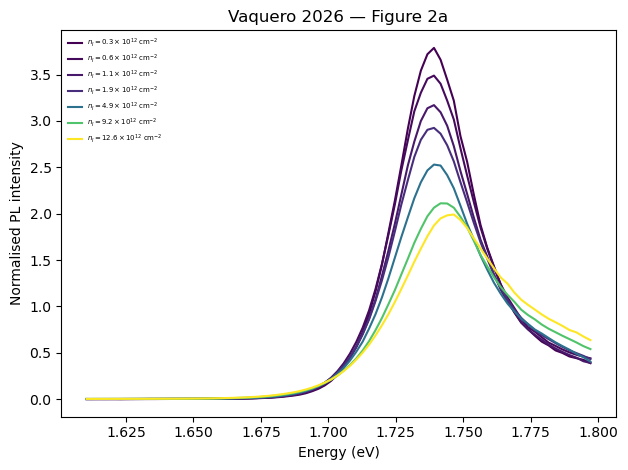

In [28]:
# Reproduce figure 2a from the reference paper

cmap      = sns.color_palette("viridis", as_cmap=True)
norm_cmap = mcolors.Normalize(vmin=min(nI_sweep.values()), vmax=max(nI_sweep.values()))
colors    = {nI: cmap(norm_cmap(nI)) for nI in nI_sweep.values()}

fig, ax = plt.subplots()

for nI_value in nI_sweep.values():
    sp = nI_sweep[nI_value]          # Spectrum directly — no inner sweep
    ax.plot(
        sp.energy,
        sp.intensity,
        color=colors[nI_value],
        linestyle='-',
        label=f'$n_I = {nI_value/1e12:.3g} \\times 10^{{12}}$ cm$^{{-2}}$',
    )

ax.set_xlabel(f'Energy ({sp.energy_unit})')
ax.set_ylabel(f'Normalised {sp.spectroscopy} intensity')
ax.legend(loc='upper left', frameon=False, fontsize=5)
ax.set_title('Vaquero 2026 — Figure 2a')
plt.tight_layout()
plt.show()

In [4]:
ref    = load_reference("WSe2_monolayer", "Dijkstra2025")

print(ref)

ReferenceDataset(material='WSe2_monolayer', source='Dijkstra2025', spectroscopy='R', sweeps={'gate_voltage': 201})

Title       : Ten-valley excitonic complexes in charge-tunable monolayer WSe2
Source      : Dijkstra2025
DOI         : 10.1038/s41467-025-65731-x
Dataset     : 10.14459/2025mp1793118
Material    : WSe2_monolayer
Measurement : R


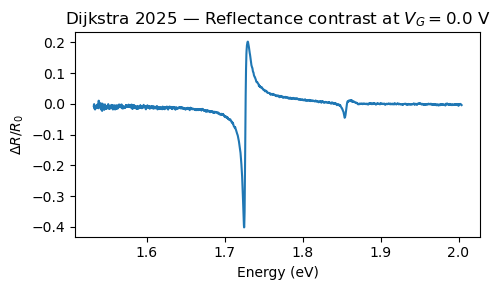

In [2]:
ref    = load_reference("WSe2_monolayer", "Dijkstra2025")
vg_sweep = ref["gate_voltage"]

# Get the default spectrum (closest to Vg=0, set at construction time)
sp = vg_sweep.default()

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(sp.energy, sp.intensity)
ax.set_xlabel(f"Energy ({sp.energy_unit})")
ax.set_ylabel(r"$\Delta R / R_0$")
ax.set_title(f"Dijkstra 2025 — Reflectance contrast at $V_G = {sp.parameter_value:.1f}$ V")
plt.tight_layout()
plt.show()

With the dataset, we can also recreate the plot made in the paper. 

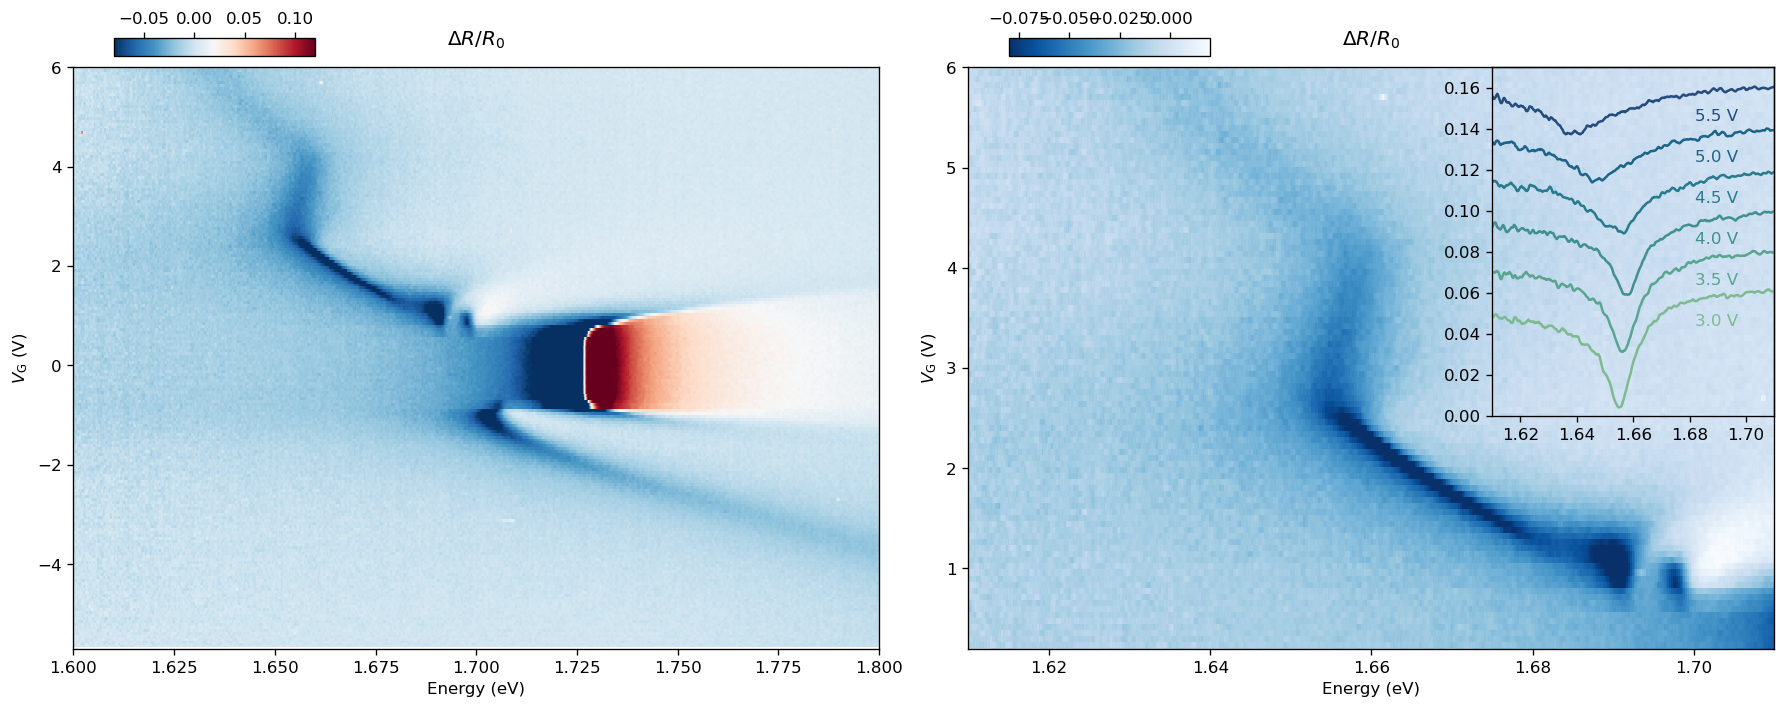

In [6]:
vg_sweep = ref["gate_voltage"]

# Reconstruct the full RC map: (n_vg, n_wl) from all sweep entries
voltages = np.array(vg_sweep.values())                        # sorted ascending
spectra  = np.array([vg_sweep[v].intensity for v in voltages])  # (n_vg, n_wl)
energy   = vg_sweep[voltages[0]].energy                       # (n_wl,)

# ---------------------------------------------------------------------------
# Helper: nearest index (mirrors authors' find_nearest_element)
# ---------------------------------------------------------------------------

def _nearest(array, value):
    return int(np.argmin(np.abs(array - value)))

def _smooth(data, kernel_size=2):
    kernel = np.ones(kernel_size) / kernel_size
    return np.convolve(data, kernel, mode="same")

# ---------------------------------------------------------------------------
# Panel 1: full gate sweep — RdBu_r colormap
# ---------------------------------------------------------------------------

fig, (ax, bx) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

# --- Left panel ---
ax.pcolormesh(
    energy, voltages, spectra,
    cmap="RdBu_r", vmin=-0.08, vmax=0.12, rasterized=True,
)
cax  = ax.inset_axes([0.05, 1.02, 0.25, 0.03])
im_l = ax.collections[-1]
fig.colorbar(im_l, cax=cax, orientation="horizontal", location="top")

ax.set_xlabel("Energy (eV)")
ax.set_ylabel(r"$V_\mathrm{G}$ (V)")
ax.set_title(r"$\Delta R/R_0$", x=0.5, y=1.02)
ax.set_xlim(1.6, 1.8)
ax.set_ylim(-5.7, 6)

# --- Right panel ---
bx.pcolormesh(
    energy, voltages, spectra,
    cmap="Blues_r", vmin=-0.08, vmax=0.02, rasterized=True,
)
cax  = bx.inset_axes([0.05, 1.02, 0.25, 0.03])
im_r = bx.collections[-1]
fig.colorbar(im_r, cax=cax, orientation="horizontal", location="top")

bx.set_xlabel("Energy (eV)")
bx.set_ylabel(r"$V_\mathrm{G}$ (V)")
bx.set_title(r"$\Delta R/R_0$", x=0.5, y=1.02)
bx.set_xlim(1.61, 1.71)
bx.set_ylim(0.2, 6)

# --- Inset on right panel: waterfall of individual spectra ---
plot_voltages = np.array([3, 3.5, 4, 4.5, 5, 5.5])
global_offset = 0.06
offset        = 0.02

axins  = bx.inset_axes([0.65, 0.4, 0.35, 0.6], xlim=(1.61, 1.71), ylim=(0, 0.17))
colors = sns.color_palette("crest", len(plot_voltages))

for i, volt in enumerate(plot_voltages):
    idx      = _nearest(voltages, volt)
    # Average the spectrum with its two neighbours to reduce noise,
    # then smooth with a box-car kernel — mirrors the authors exactly
    loc_data = (spectra[idx - 1] + spectra[idx] + spectra[idx + 1]) / 3
    loc_data = _smooth(loc_data, kernel_size=6)
    axins.plot(energy, loc_data + i * offset + global_offset, color=colors[i])
    axins.text(
        1.682, i * offset + global_offset - 0.016,
        f"{volt:.1f} V",
        color=colors[i],
    )

axins.set_facecolor("none")

plt.tight_layout()
plt.show()